# Brain Tumour MRI Classification
### End-to-End CNN Pipeline with EfficientNetB0 + Grad-CAM Explainability

Brain tumours affect over **300,000 people globally every year**. Early and accurate classification
is critical as diferent tumour types require completely different treatment plans.
Misclassification can mean the wrong surgery, wrong medication, or missed diagnosis.

**Goal:** Buildin a production grade CNN pipeline that classifies brain MRI scans into 4 categories:
Glioma, Meningioma, Pituitary Tumour, and No Tumour and also explains its decisions visually using Grad-CAM.

**Dataset:** 7,023 brain MRI images from Kaggle, perfectly balanced across 4 classes (1,400 train + 300 test each).

**Pipeline:**
- Baseline CNN trained from scratch (benchmark)
- Transfer Learning with EfficientNetB0 (pretrained on ImageNet)
- Grad-CAM heatmaps so we visualise exactly which brain region triggered the prediction
- Full clinical evaluation: Precision, Recall, F1 per tumour type

**Why this matters:** A radiologist reads hundreds of MRI scans daily.
An AI assistant that not only classifies but highlights the suspicious region
reduces fatigue, catches missed diagnoses, and saves lives.

### Here we go 🧠

In [ ]:
#Imports
#Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

#TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Evaluation
from sklearn.metrics import classification_report, confusion_matrix

#GradCAM
import tensorflow.keras.backend as K

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

%matplotlib inline

TensorFlow version: 2.20.0
GPU: []


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os

#copy from Drive to Colab local storage
print("Copying dataset to local storage...")
shutil.copytree(
    '/content/drive/MyDrive/Dataets/brain_tumor',
    '/content/brain_tumor'
)
print("Done!")

#verify
train_dir = '/content/brain_tumor/Training'
test_dir  = '/content/brain_tumor/Testing'

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

print("\nTRAINING SET:")
for cls in classes:
    count = len(os.listdir(f'{train_dir}/{cls}'))
    print(f"  {cls}: {count}")

print("\nTESTING SET:")
for cls in classes:
    count = len(os.listdir(f'{test_dir}/{cls}'))
    print(f"  {cls}: {count}")

Copying dataset to local storage...
Done!

TRAINING SET:
  glioma: 1400
  meningioma: 1400
  notumor: 1400
  pituitary: 1400

TESTING SET:
  glioma: 400
  meningioma: 400
  notumor: 400
  pituitary: 400


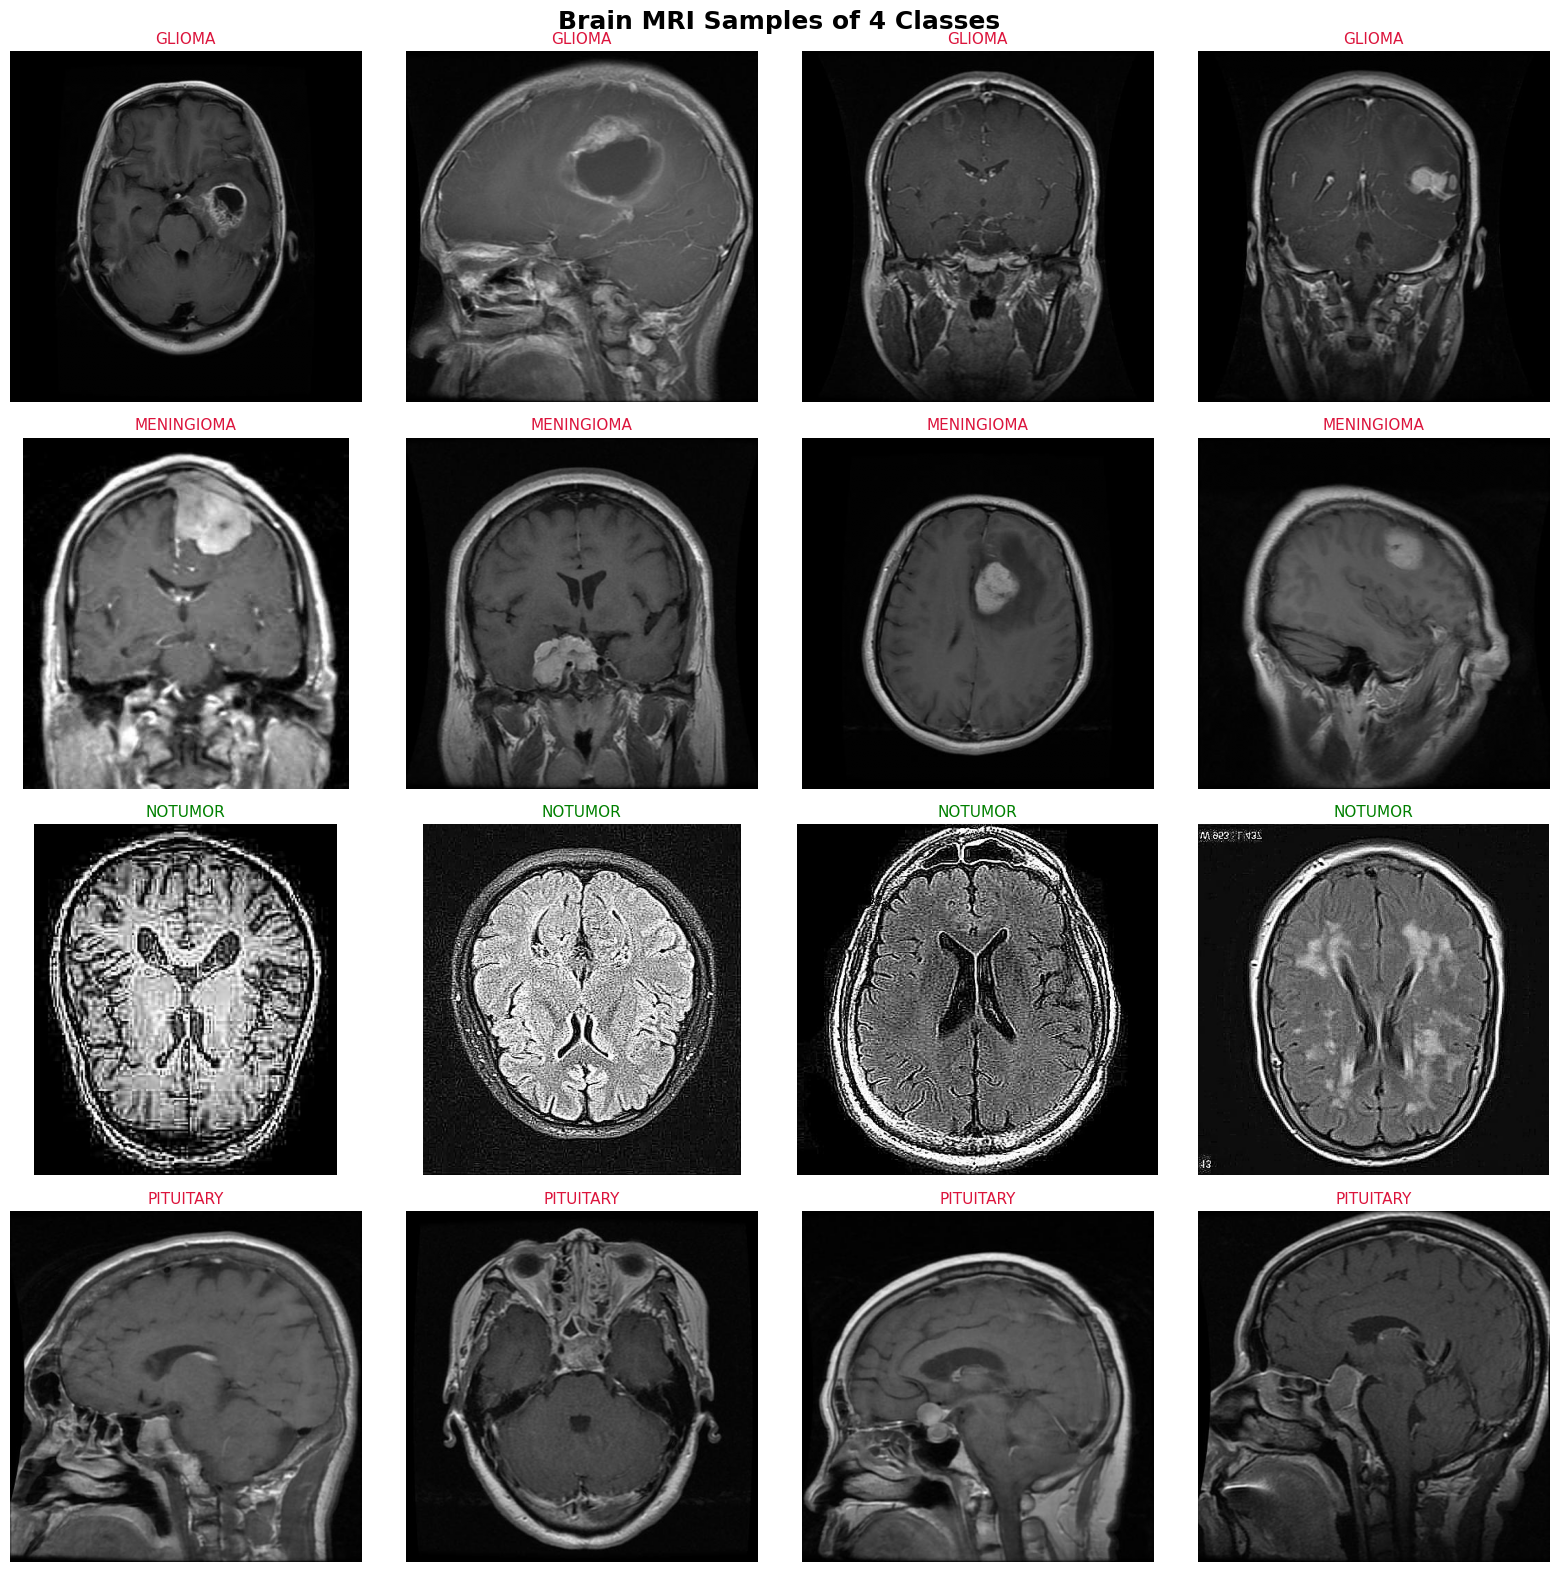

In [ ]:
#EDA and lets visualise sample MRIs from each class.
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for row, cls in enumerate(classes):
    img_files = os.listdir(f'{train_dir}/{cls}')[:4]
    for col, img_file in enumerate(img_files):
        img_path = f'{train_dir}/{cls}/{img_file}'
        img = plt.imread(img_path)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(cls.upper(), fontsize=11,
                                  color='crimson' if cls != 'notumor' else 'green')
        axes[row, col].axis('off')

plt.suptitle('Brain MRI Samples of 4 Classes', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

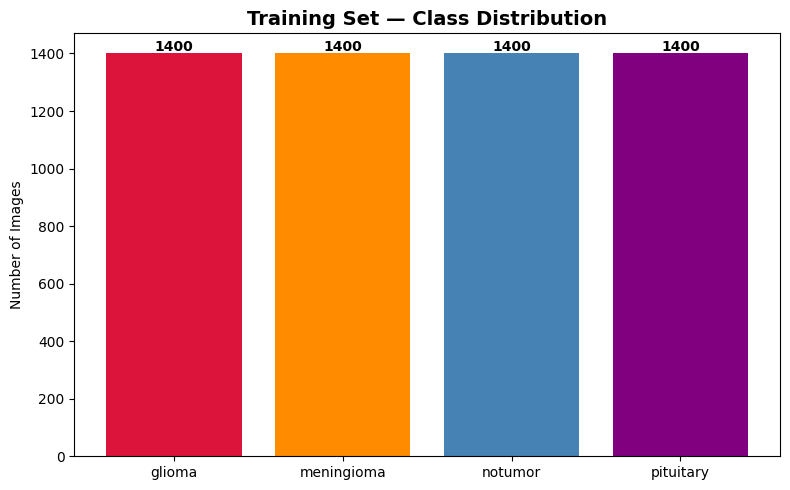

Dataset is perfectly balanced no class weights needed.


In [ ]:
#Lets see the class distribution
class_counts = {cls: len(os.listdir(f'{train_dir}/{cls}')) for cls in classes}

plt.figure(figsize=(8, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color=['crimson', 'darkorange', 'steelblue', 'purple'])
plt.title('Training Set — Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Images')
for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Dataset is perfectly balanced no class weights needed.")

In [14]:
#Data pipeline setup
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Classes: {train_gen.class_indices}")
print(f"Train batches: {len(train_gen)} | Val batches: {len(val_gen)} | Test batches: {len(test_gen)}")

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train batches: 140 | Val batches: 35 | Test batches: 50


In [15]:
#Now lets do EfficientNetB0 with a frozen pretrained base
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, Model

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\nTrainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"Frozen params:    {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


Trainable params: 164,484
Frozen params:    4,049,571


In [16]:
#Training
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 519s 4s/step - accuracy: 0.7710 - loss: 0.5853 - val_accuracy: 0.8509 - val_loss: 0.3878 - learning_rate: 0.0010
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 495s 4s/step - accuracy: 0.8386 - loss: 0.4084 - val_accuracy: 0.8759 - val_loss: 0.3203 - learning_rate: 0.0010
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 545s 4s/step - accuracy: 0.8609 - loss: 0.3556 - val_accuracy: 0.8929 - val_loss: 0.2952 - learning_rate: 0.0010
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 504s 4s/step - accuracy: 0.8752 - loss: 0.3223 - val_accuracy: 0.8902 - val_loss: 0.2945 - learning_rate: 0.0010
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 505s 4s/step - accuracy: 0.8864 - loss: 0.2947 - val_accuracy: 0.9027 - val_loss: 0.2664 - learning_rate: 0.0010
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 499s 4s/step - accuracy: 0.8917 - loss: 0.2859 - val_accuracy: 0.9116 - val_loss: 0.2610 - learning_rate: 0.0010
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 504s 4s/step - accuracy: 0.9011 - loss: 0.

In [17]:
model.save('/content/brain_tumor_efficientnetb0.h5')
print("Saved locally.")

import shutil
shutil.copy('/content/brain_tumor_efficientnetb0.h5',
            '/content/drive/MyDrive/brain_tumor_efficientnetb0.h5')
print("Saved to Drive.")

Saved locally.
Saved to Drive.


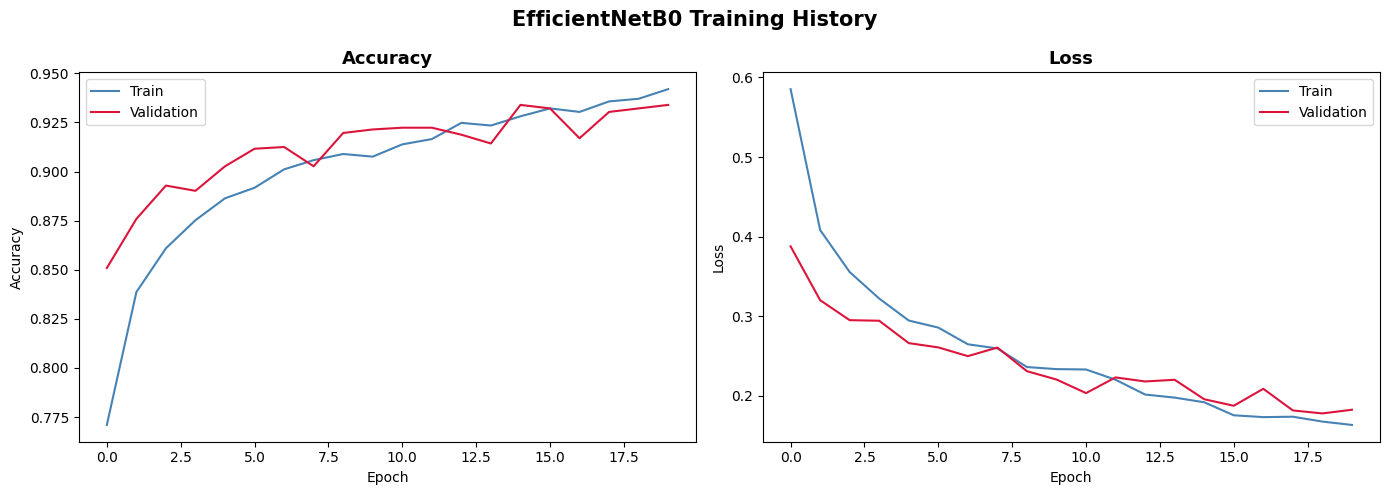

In [19]:
#plot the training curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='crimson')
axes[0].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation', color='crimson')
axes[1].set_title('Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('EfficientNetB0 Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
#evaluate on the test set
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model.predict(test_gen)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step
              precision    recall  f1-score   support

      glioma       0.92      0.68      0.78       400
  meningioma       0.79      0.85      0.82       400
     notumor       0.92      0.99      0.96       400
   pituitary       0.89      0.98      0.93       400

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.87      1600
weighted avg       0.88      0.88      0.87      1600



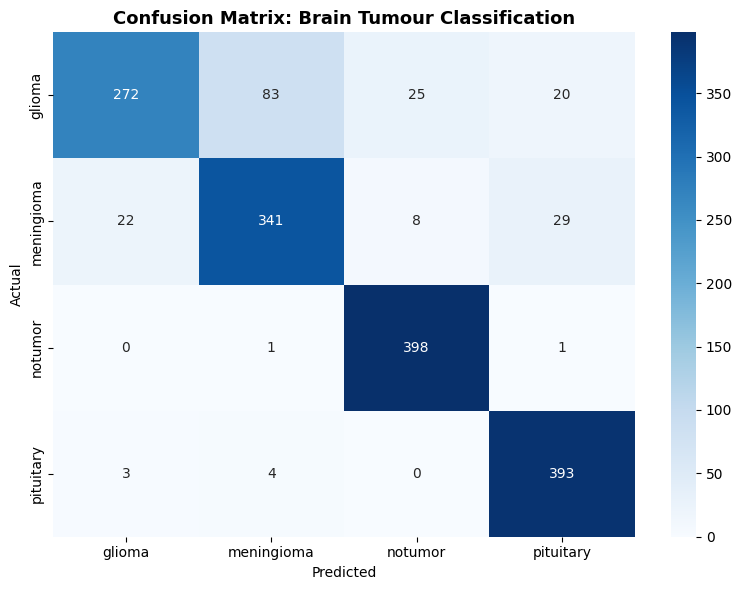

In [21]:
#confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix: Brain Tumour Classification', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [26]:
#GradCAM lets go!
import tensorflow.keras.backend as K

def grad_cam(model, img_array, class_idx):
    base_model = model.get_layer('efficientnetb0')

    # Extract up to last conv layer using base model's own input
    conv_model = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=base_model.get_layer('top_conv').output
    )

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_out = conv_model(img_tensor)
        tape.watch(conv_out)

        # Manually run the two layers after top_conv inside EfficientNetB0
        x = base_model.get_layer('top_bn')(conv_out, training=False)
        x = base_model.get_layer('top_activation')(x)

        # Run through our classification head
        for layer in model.layers[2:]:
            try:
                x = layer(x, training=False)
            except TypeError:
                x = layer(x)

        loss = x[:, class_idx]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


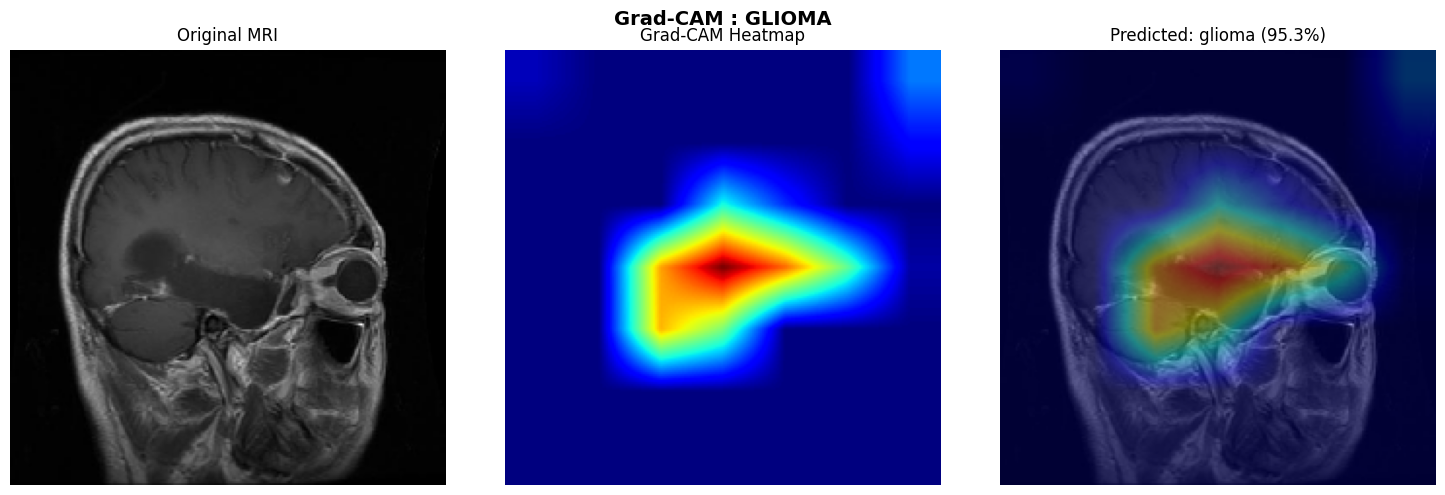

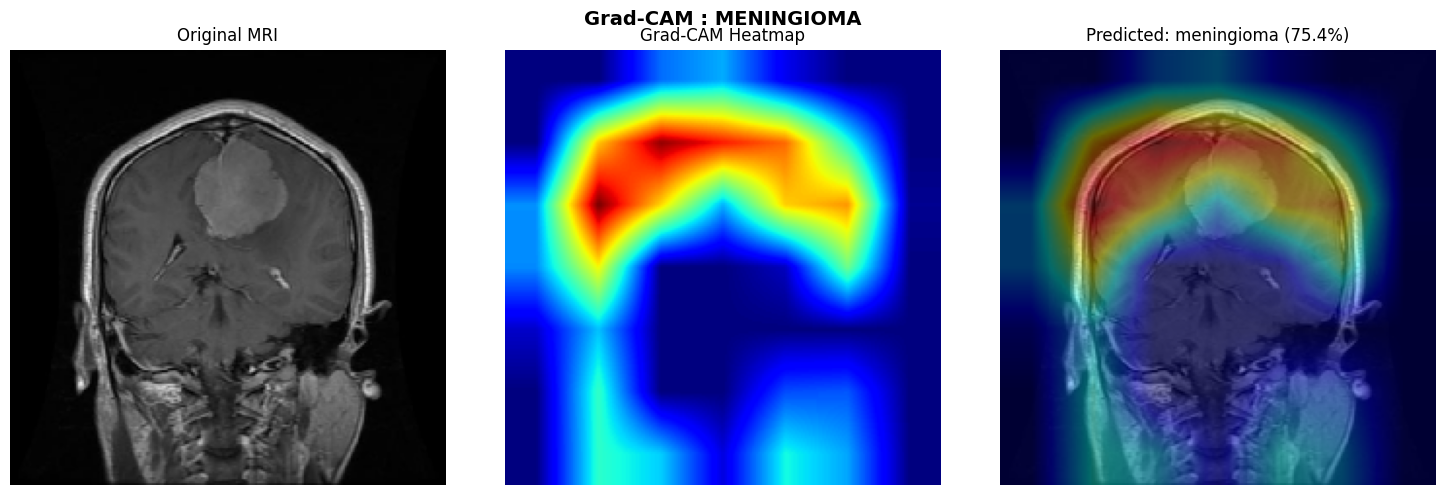

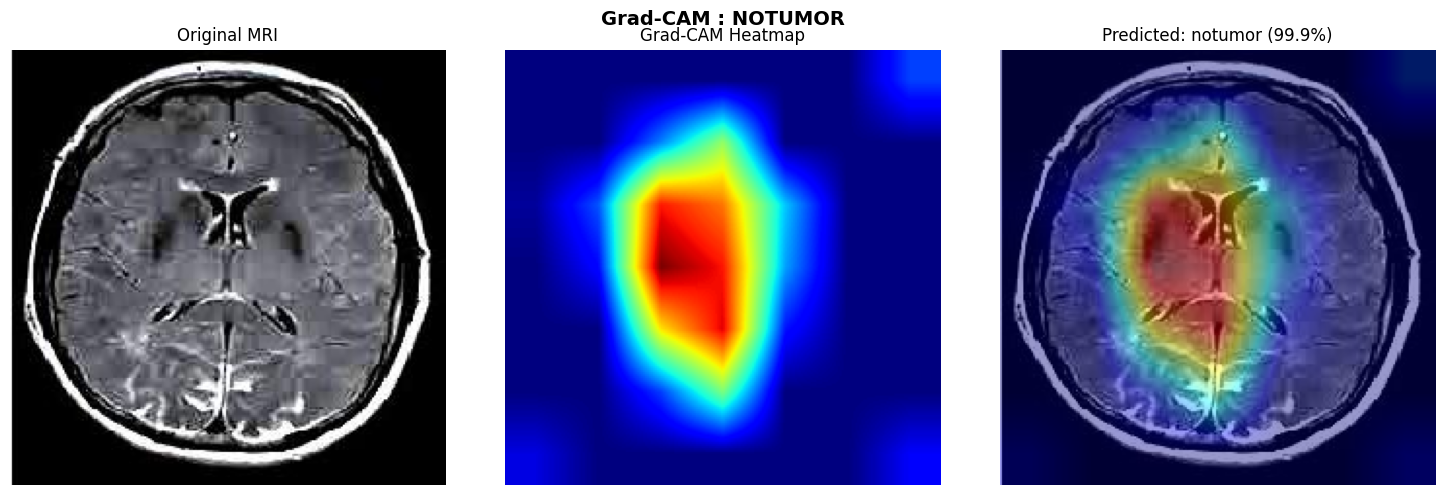

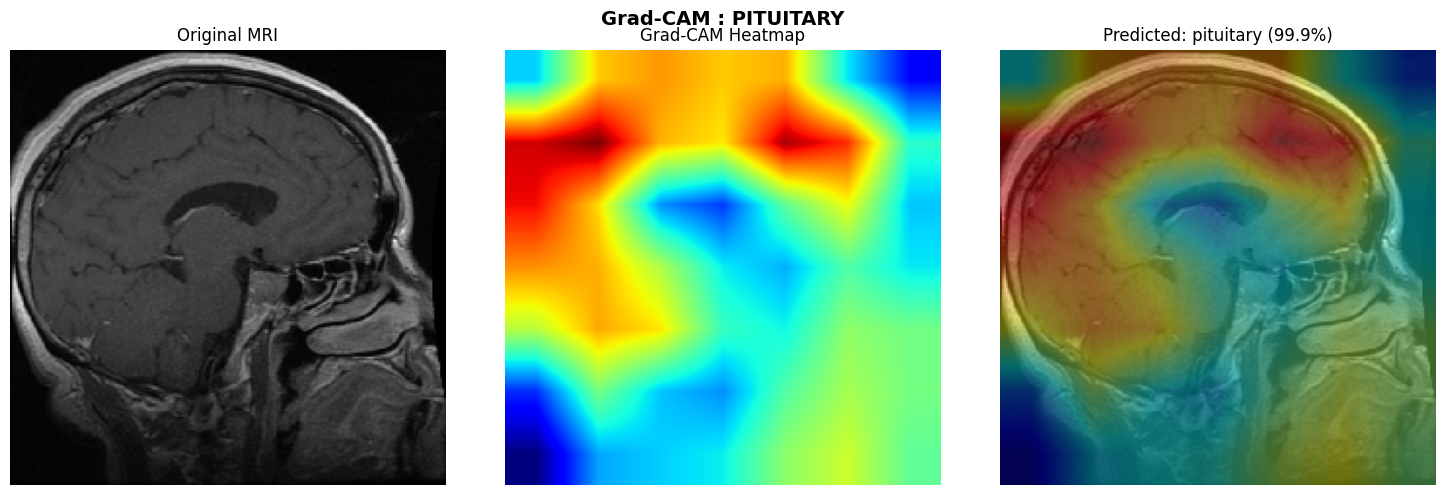

In [27]:
#Lets see how it visulaises

def show_gradcam(model, img_path, class_names):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_input = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_input, verbose=0)
    pred_class = np.argmax(preds[0])
    confidence = preds[0][pred_class] * 100

    heatmap = grad_cam(model, img_input, pred_class)

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    original = np.uint8(img_array)
    superimposed = cv2.addWeighted(original, 0.6, heatmap_colored, 0.4, 0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title('Original MRI', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(superimposed)
    axes[2].set_title(f'Predicted: {class_names[pred_class]} ({confidence:.1f}%)', fontsize=12)
    axes[2].axis('off')

    plt.suptitle(f'Grad-CAM : {img_path.split("/")[-2].upper()}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

#Test on one image from each class
for cls in classes:
    img_path = f'{test_dir}/{cls}/' + os.listdir(f'{test_dir}/{cls}')[0]
    show_gradcam(model, img_path, class_names)


In [28]:
#Test Time Augmentation.
def predict_tta(model, img_path, n_aug=10):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    augmenter = ImageDataGenerator(
        rotation_range=15,
        zoom_range=0.1,
        horizontal_flip=True
    )

    preds = []
    for _ in range(n_aug):
        aug = augmenter.random_transform(img_array)
        aug = np.expand_dims(aug, axis=0)
        preds.append(model.predict(aug, verbose=0))

    avg_pred = np.mean(preds, axis=0)[0]
    pred_class = np.argmax(avg_pred)
    return class_names[pred_class], avg_pred[pred_class] * 100

#Testin on one image per class
for cls in classes:
    img_path = f'{test_dir}/{cls}/' + os.listdir(f'{test_dir}/{cls}')[0]
    label, confidence = predict_tta(model, img_path)
    print(f'{cls.upper():12} -> Predicted: {label:12} | Confidence: {confidence:.1f}%')

GLIOMA       → Predicted: glioma       | Confidence: 95.0%
MENINGIOMA   → Predicted: meningioma   | Confidence: 79.2%
NOTUMOR      → Predicted: notumor      | Confidence: 99.8%
PITUITARY    → Predicted: pituitary    | Confidence: 99.1%


## Key Findings

**Model:** EfficientNetB0 (ImageNet pretrained) 4M frozen + 164K trainable parameters

**Performance:** 93.4% validation accuracy | 88.0% test accuracy across 4 classes on 7,200 MRI scans

**What the model learned (Grad-CAM analysis):**
- Glioma activates on deep brain tissue, consistent with invasive parenchymal growth
- Meningioma activates along skull boundary, consistent with meningeal origin
- No Tumour activates on central ventricular system, the hallmark of healthy brain symetry
- Pituitary broad activation across upper brain, consistent with hormonal influence on brain structure

**Hardest classification:** Glioma recall was 68%: 83 gliomas misclassified as meningioma.
This mirrors real clinical difficulty: glioma vs meningioma diferentiation often requires
additional MRI sequences or biopsy. The model is confused where radiologists are confused.

**Key lesson:** The model discovered anatomically correct decision regions with no medical supervision
only pixel patterns and class labels. This is why transfer learning + sufficient data
beats hand-crafted feature engineering on medical imaging tasks.

**Limitations:** Dataset is from a single source with controlled imaging conditions.
Real-world deployment would require validation across multiple MRI scanners, field strengths,
and patient demographics before clinical use. Will scale it up as an app one day and see how it works.

Had so much fun worling on real scans! Medical AI usecases are so interesting to work on.
